# 1. Setup & Dependencies

This cell installs the required deep learning and visualization libraries, specifically **TensorFlow** (the framework that powers MobileNetV2). It also imports essential Python modules for computer vision (`PIL`), matrix operations (`numpy`), data visualization (`matplotlib`, `seaborn`), evaluation metrics (`scikit-learn`), and file management necessary for processing our datasets. *Note: The `--quiet` flag ensures a clean installation output.*

In [2]:
!pip install tensorflow matplotlib seaborn scikit-learn pyyaml --quiet

import os, yaml, shutil, zipfile, glob, random, warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive

warnings.filterwarnings('ignore')
print('✅ Dependencies loaded.')
print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

✅ Dependencies loaded.
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 2. Configuration & Global Class Mapping

This cell defines the core parameters of the project, specifically for **MobileNetV2** (the architecture powering our image classification). It establishes the list of supported fruits and their target ripeness stages to generate a Unified Global Class Map. It also sets essential deep learning hyperparameters for model training (`ALPHA`, `IMG_SIZE`, `BATCH_SIZE`), phase-specific learning rates (`LR_HEAD`, `LR_FINETUNE`), and color codes necessary for visualizing our predictions (`FRUIT_COLORS`). *Note: The `EPOCHS_FROZEN` and `EPOCHS_FINETUNE` variables control the two-stage transfer learning process.*

In [3]:
FRUITS    = ['Avocado', 'Guava', 'Mango', 'Pineapple', 'Banana']
RIPENESS  = ['Overripe', 'Ripe', 'Unripe']
CLASS_NAMES = [f'{f}_{r}' for f in FRUITS for r in RIPENESS]
NUM_CLASSES  = len(CLASS_NAMES)   # 15

# MobileNetV2 α=0.5 config
ALPHA          = 0.5
IMG_SIZE       = 224
BATCH_SIZE     = 32
EPOCHS_FROZEN  = 10   # Train head only
EPOCHS_FINETUNE= 40   # Unfreeze & fine-tune
LR_HEAD        = 1e-3
LR_FINETUNE    = 1e-5
PATIENCE       = 10
VAL_RATIO      = 0.15
TEST_RATIO     = 0.10

FRUIT_COLORS = {
    'Avocado':'#2ECC71','Guava':'#E74C3C',
    'Mango':'#F39C12','Pineapple':'#F1C40F','Banana':'#F4D35E'
}

print('=== GLOBAL CLASS MAP ===')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {i:2d}: {name}')
print(f'\nMobileNetV2 alpha = {ALPHA}')

=== GLOBAL CLASS MAP ===
   0: Avocado_Overripe
   1: Avocado_Ripe
   2: Avocado_Unripe
   3: Guava_Overripe
   4: Guava_Ripe
   5: Guava_Unripe
   6: Mango_Overripe
   7: Mango_Ripe
   8: Mango_Unripe
   9: Pineapple_Overripe
  10: Pineapple_Ripe
  11: Pineapple_Unripe
  12: Banana_Overripe
  13: Banana_Ripe
  14: Banana_Unripe

MobileNetV2 alpha = 0.5


# 3. Storage Mounting & Path Verification

This cell mounts Google Drive to access the persistent fruit datasets and save trained models. It defines the exact paths for the individual fruit ZIP files (`ZIP_PATHS`), creates output directories for the merged dataset and Keras-compatible classification structure (`CLF_DIR`), and runs a built-in path checker to verify file existence before proceeding.

In [4]:
drive.mount('/content/drive')

ZIP_PATHS = [
    '/content/drive/MyDrive/DEEP LEARNING/YOLO26/data/Avocado',
    '/content/drive/MyDrive/DEEP LEARNING/YOLO26/data/Mango',
    '/content/drive/MyDrive/DEEP LEARNING/YOLO26/data/Pineapple',
    '/content/drive/MyDrive/DEEP LEARNING/YOLO26/data/Guava',
    '/content/drive/MyDrive/DEEP LEARNING/YOLO26/data/Banana',
]

DATASET_DIR  = '/content/merged_dataset'
CLF_DIR      = '/content/clf_dataset'   # Keras folder structure
MODEL_DIR    = '/content/drive/MyDrive/DEEP LEARNING/YOLO26/models'
os.makedirs(MODEL_DIR, exist_ok=True)

print('\n🔍 Checking paths...')
for p in ZIP_PATHS:
    status = '✅' if os.path.exists(p) else '❌'
    print(f'  {status} {p}')

Mounted at /content/drive

🔍 Checking paths...
  ✅ /content/drive/MyDrive/DEEP LEARNING/YOLO26/data/Avocado
  ✅ /content/drive/MyDrive/DEEP LEARNING/YOLO26/data/Mango
  ✅ /content/drive/MyDrive/DEEP LEARNING/YOLO26/data/Pineapple
  ✅ /content/drive/MyDrive/DEEP LEARNING/YOLO26/data/Guava
  ✅ /content/drive/MyDrive/DEEP LEARNING/YOLO26/data/Banana


# 4. Automated Dataset Integration & Cleaning

This cell extracts the raw dataset for each fruit and reads the internal `data.yaml` to identify local class mappings. It translates these local IDs into the Unified Global Class Map and consolidates the validated image-label pairs into a unified directory structure. Any corrupted images, missing label files, or invalid class IDs are automatically skipped to maintain data integrity.

In [5]:
def integrate_datasets(zip_paths, output_dir, class_names, fruits, ripeness):
    for split in ['train', 'valid', 'test']:
        os.makedirs(f'{output_dir}/{split}/images', exist_ok=True)
        os.makedirs(f'{output_dir}/{split}/labels', exist_ok=True)

    stats  = {n: 0 for n in class_names}
    errors = []

    for zip_path in zip_paths:
        fruit = Path(zip_path).stem.split('.')[0]
        print(f"\n{'─'*55}\nProcessing: {fruit}")
        tmp = f'/content/tmp_{fruit}'
        if os.path.exists(tmp): shutil.rmtree(tmp)

        if os.path.isdir(zip_path):
            shutil.copytree(zip_path, tmp)
        else:
            try:
                with zipfile.ZipFile(zip_path, 'r') as z: z.extractall(tmp)
            except Exception as e:
                errors.append(f'{fruit}: {e}'); continue

        yaml_candidates = glob.glob(f'{tmp}/**/*.yaml', recursive=True)
        local_classes = None
        for yp in yaml_candidates:
            with open(yp) as f: d = yaml.safe_load(f)
            if 'names' in d:
                local_classes = d['names']
                print(f'  ✅ data.yaml: {local_classes}'); break

        if local_classes is None:
            local_classes = [f'{fruit}_{r}' for r in ripeness]
            print(f'  ☐  No yaml, assuming: {local_classes}')

        local_to_global = {}
        for lid, lname in enumerate(local_classes):
            full = lname if fruit.lower() in lname.lower() else f'{fruit}_{lname}'
            if full in class_names:
                local_to_global[lid] = class_names.index(full)
            else:
                errors.append(f"{fruit}: '{full}' not in CLASS_NAMES")

        for split in ['train', 'valid', 'test', '']:
            base_split = os.path.join(tmp, split) if split else tmp
            src_img = os.path.join(base_split, 'images')
            src_lbl = os.path.join(base_split, 'labels')
            if not os.path.exists(src_img): continue

            ok, skip = 0, 0
            for img_file in os.listdir(src_img):
                if not img_file.lower().endswith(('.jpg','.jpeg','.png')): continue
                stem     = Path(img_file).stem
                lbl_path = os.path.join(src_lbl, stem + '.txt')
                if not os.path.exists(lbl_path): skip += 1; continue

                new_lines, valid = [], True
                with open(lbl_path) as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) < 5: continue
                        lid = int(parts[0])
                        if lid not in local_to_global: valid = False; break
                        gid = local_to_global[lid]
                        new_lines.append(f"{gid} {' '.join(parts[1:])}")

                if not valid: skip += 1; continue
                target_split = split if split else 'train'
                dst_img = f'{output_dir}/{target_split}/images/{fruit}_{img_file}'
                dst_lbl = f'{output_dir}/{target_split}/labels/{fruit}_{stem}.txt'
                shutil.copy2(os.path.join(src_img, img_file), dst_img)
                with open(dst_lbl, 'w') as f: f.write('\n'.join(new_lines))
                stats[class_names[gid]] += 1
                ok += 1

            if ok > 0: print(f'  [{split or "root"}] ✅ {ok} | ☐ {skip} skipped')

        shutil.rmtree(tmp)

    print(f"\nIntegration complete. Errors: {len(errors)}")
    return stats, errors

if os.path.exists(DATASET_DIR): shutil.rmtree(DATASET_DIR)
stats, errors = integrate_datasets(ZIP_PATHS, DATASET_DIR, CLASS_NAMES, FRUITS, RIPENESS)


───────────────────────────────────────────────────────
Processing: Avocado
  ✅ data.yaml: ['Avocado_Overripe', 'Avocado_Ripe', 'Avocado_Unripe']
  [train] ✅ 907 | ☐ 56 skipped

───────────────────────────────────────────────────────
Processing: Mango
  ✅ data.yaml: ['Mango_Overripe', 'Mango_Ripe', 'Mango_Unripe']
  [train] ✅ 980 | ☐ 75 skipped

───────────────────────────────────────────────────────
Processing: Pineapple
  ✅ data.yaml: ['Pineapple_Overripe', 'Pineapple_Ripe', 'Pineapple_Unripe']
  [train] ✅ 530 | ☐ 31 skipped

───────────────────────────────────────────────────────
Processing: Guava
  ✅ data.yaml: ['Guava_Overripe', 'Guava_Ripe', 'Guava_Unripe']
  [train] ✅ 893 | ☐ 50 skipped

───────────────────────────────────────────────────────
Processing: Banana
  ✅ data.yaml: ['Banana_Overripe', 'Banana_Ripe', 'Banana_Unripe']
  [train] ✅ 4221 | ☐ 0 skipped

Integration complete. Errors: 0


# 5. Automated Dataset Splitting

This cell divides the unified dataset into separate splits required for machine learning model evaluation.

* **Validation Set (15%):** Used during training to monitor performance and prevent overfitting.
* **Test Set (10%):** Kept strictly isolated for final, unbiased model evaluation.
* **Process:** Shuffles the complete dataset and mathematically allocates files based on the defined ratios.
* **File Management:** Automatically moves both the image files (`.jpg`, `.png`) and their corresponding YOLO label files (`.txt`) into their newly designated directories.

In [6]:
def create_splits(base_dir, val_ratio=0.15, test_ratio=0.10):
    train_img = f'{base_dir}/train/images'
    train_lbl = f'{base_dir}/train/labels'
    files = [f for f in os.listdir(train_img) if f.endswith(('.jpg','.png','.jpeg'))]
    random.shuffle(files)
    n_val  = int(len(files) * val_ratio)
    n_test = int(len(files) * test_ratio)
    for sname, sfiles in [('valid', files[:n_val]), ('test', files[n_val:n_val+n_test])]:
        print(f'📁 {sname}: {len(sfiles)} files')
        for f in sfiles:
            stem = os.path.splitext(f)[0]
            shutil.move(f'{train_img}/{f}', f'{base_dir}/{sname}/images/{f}')
            lp = f'{train_lbl}/{stem}.txt'
            if os.path.exists(lp):
                shutil.move(lp, f'{base_dir}/{sname}/labels/{stem}.txt')

create_splits(DATASET_DIR)

📁 valid: 1087 files
📁 test: 724 files


# 6. Formatting Dataset for Keras Classification

Because MobileNetV2 requires a different folder structure than YOLOv8, this cell executes an automated format conversion. It reads the unified YOLO bounding boxes, physically crops the exact pixel area of every individual fruit out of the larger image, resizes the crop to match MobileNetV2's required input resolution (`224x224`), and saves the resulting image directly into a dynamically generated folder matching its correct class name (e.g., `clf_dataset/train/Avocado_Ripe/image.jpg`).

In [7]:
def yolo_dataset_to_clf(yolo_dir, clf_dir, class_names, img_size=224):
    """
    Converts YOLO-format dataset to Keras ImageDataGenerator folder structure.
    Crops each bounding box → saves as individual class-labelled image.
    Structure: clf_dir/split/ClassName/image.jpg
    """
    if os.path.exists(clf_dir): shutil.rmtree(clf_dir)

    counts = {s: {c: 0 for c in class_names} for s in ['train','valid','test']}

    for split in ['train', 'valid', 'test']:
        img_dir = os.path.join(yolo_dir, split, 'images')
        lbl_dir = os.path.join(yolo_dir, split, 'labels')
        if not os.path.exists(img_dir): continue

        for cls in class_names:
            os.makedirs(os.path.join(clf_dir, split, cls), exist_ok=True)

        for img_file in os.listdir(img_dir):
            if not img_file.lower().endswith(('.jpg','.jpeg','.png')): continue
            stem = Path(img_file).stem
            lbl_path = os.path.join(lbl_dir, stem + '.txt')
            img_path = os.path.join(img_dir, img_file)

            img = Image.open(img_path).convert('RGB')
            W, H = img.size

            if not os.path.exists(lbl_path):
                continue

            with open(lbl_path) as f:
                lines = f.readlines()

            for idx, line in enumerate(lines):
                parts = line.strip().split()
                if len(parts) < 5: continue
                cls_id = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:5])

                x1 = int((cx - bw/2) * W)
                y1 = int((cy - bh/2) * H)
                x2 = int((cx + bw/2) * W)
                y2 = int((cy + bh/2) * H)
                x1,y1 = max(0,x1), max(0,y1)
                x2,y2 = min(W,x2), min(H,y2)

                if x2 <= x1 or y2 <= y1: continue

                crop = img.crop((x1,y1,x2,y2)).resize((img_size, img_size))
                cls_name = class_names[cls_id]
                out_path = os.path.join(clf_dir, split, cls_name, f'{stem}_{idx}.jpg')
                crop.save(out_path, 'JPEG', quality=90)
                counts[split][cls_name] += 1

    print('\n=== CLF DATASET SUMMARY ===')
    for split in ['train','valid','test']:
        total = sum(counts[split].values())
        print(f'\n  {split.upper()} — {total} crops')
        for cls in class_names:
            print(f'    {cls:25s}: {counts[split][cls]}')
    return counts

clf_counts = yolo_dataset_to_clf(DATASET_DIR, CLF_DIR, CLASS_NAMES, IMG_SIZE)
print('\n✅ CLF dataset ready at', CLF_DIR)


=== CLF DATASET SUMMARY ===

  TRAIN — 14393 crops
    Avocado_Overripe         : 230
    Avocado_Ripe             : 220
    Avocado_Unripe           : 235
    Guava_Overripe           : 317
    Guava_Ripe               : 471
    Guava_Unripe             : 471
    Mango_Overripe           : 1465
    Mango_Ripe               : 3081
    Mango_Unripe             : 4581
    Pineapple_Overripe       : 195
    Pineapple_Ripe           : 81
    Pineapple_Unripe         : 119
    Banana_Overripe          : 1244
    Banana_Ripe              : 1104
    Banana_Unripe            : 579

  VALID — 1942 crops
    Avocado_Overripe         : 42
    Avocado_Ripe             : 64
    Avocado_Unripe           : 41
    Guava_Overripe           : 79
    Guava_Ripe               : 46
    Guava_Unripe             : 103
    Mango_Overripe           : 215
    Mango_Ripe               : 539
    Mango_Unripe             : 155
    Pineapple_Overripe       : 45
    Pineapple_Ripe           : 21
    Pineapple_Unrip

# 7. Data Augmentation & Generator Setup

This cell configures the Keras `ImageDataGenerator` pipelines to efficiently feed images into the MobileNetV2 model during training. The training generator applies real-time data augmentation—such as random rotations, shifts, flips, zoom, and brightness adjustments—to artificially expand the dataset and prevent the model from memorizing specific images (overfitting). Conversely, the validation and test generators strictly apply pixel normalization (rescaling values from 0-255 down to 0-1) without any augmentation to ensure an accurate, unbiased evaluation. Finally, the `flow_from_directory` function connects these generators to the previously created folder structure, automatically assigning the correct one-hot encoded labels and batching the images for memory-efficient processing.

In [8]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(CLF_DIR, 'train'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(CLF_DIR, 'valid'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(CLF_DIR, 'test'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False
)

print(f'\nTrain: {train_gen.samples} | Val: {val_gen.samples} | Test: {test_gen.samples}')

Found 14393 images belonging to 15 classes.
Found 1942 images belonging to 15 classes.
Found 1294 images belonging to 15 classes.

Train: 14393 | Val: 1942 | Test: 1294


# 8. Model Architecture Setup (MobileNetV2)

This cell defines and constructs the core deep learning architecture. It imports the pre-trained **MobileNetV2** base model, utilizing the previously defined `alpha` parameter to scale the network's size and computational complexity. The default ImageNet classification layers are stripped away (`include_top=False`), and the base weights are completely frozen to retain their learned feature-extraction capabilities.

A custom classification head is then attached to the base. This head compresses the extracted features using Global Average Pooling, stabilizes learning with Batch Normalization, and processes the patterns through dense layers. Dropout layers are intentionally injected to randomly deactivate neurons during training, which prevents the network from memorizing the training data (overfitting). Finally, a Softmax output layer produces the final probability scores for the 15 distinct fruit ripeness classes.

In [9]:
def build_mobilenetv2(alpha, num_classes, img_size=224):
    base = MobileNetV2(
        input_shape=(img_size, img_size, 3),
        alpha=alpha,
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False   # Frozen for phase 1

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=out)
    return model, base

model, base_model = build_mobilenetv2(ALPHA, NUM_CLASSES, IMG_SIZE)
model.summary()

trainable = sum(1 for l in model.layers if l.trainable)
total     = len(model.layers)
print(f'\nTotal layers: {total} | Trainable (head only): {trainable}')
print(f'Total params: {model.count_params():,}')

3201480/3201480 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        432 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │         64 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (Conv2D)            │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         32 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │        384 │ expanded_conv_pr… │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        192 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        432 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        192 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │        768 │ block_1_depthwis

 Total params: 1,074,111 (4.10 MB)

 Trainable params: 365,327 (1.39 MB)

 Non-trainable params: 708,784 (2.70 MB)


Total layers: 161 | Trainable (head only): 7
Total params: 1,074,111


# 9. Phase 1 Training: Classification Head

This cell initiates the first phase of the transfer learning process. It compiles the model using the Adam optimizer and Categorical Crossentropy loss, tracking both standard and Top-3 accuracy. Crucially, it establishes three automated callbacks: Early Stopping (to halt training if validation accuracy plateaus and prevent overfitting), Learning Rate Reduction (to make finer parameter adjustments when learning stalls), and Model Checkpointing (to automatically save the best-performing weights). Finally, it executes the training loop exclusively on the custom classification head while the base MobileNetV2 layers remain completely frozen.

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_HEAD),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

callbacks_phase1 = [
    tf.keras.callbacks.EarlyStopping(patience=PATIENCE, restore_best_weights=True, monitor='val_accuracy'),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-7, monitor='val_loss'),
    tf.keras.callbacks.ModelCheckpoint('/content/best_head_05.keras', save_best_only=True, monitor='val_accuracy'),
]

print('=== PHASE 1: Training classification head (α=0.5) ===')
history1 = model.fit(
    train_gen,
    epochs=EPOCHS_FROZEN,
    validation_data=val_gen,
    callbacks=callbacks_phase1,
    verbose=1
)
print('✅ Phase 1 complete')

=== PHASE 1: Training classification head (α=0.5) ===
Epoch 1/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 258s 522ms/step - accuracy: 0.8132 - loss: 0.5633 - top3_acc: 0.9495 - val_accuracy: 0.8939 - val_loss: 0.3277 - val_top3_acc: 0.9907 - learning_rate: 0.0010
Epoch 2/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 202s 449ms/step - accuracy: 0.8775 - loss: 0.3402 - top3_acc: 0.9851 - val_accuracy: 0.8944 - val_loss: 0.2927 - val_top3_acc: 0.9943 - learning_rate: 0.0010
Epoch 3/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 206s 458ms/step - accuracy: 0.8897 - loss: 0.2984 - top3_acc: 0.9902 - val_accuracy: 0.8955 - val_loss: 0.2801 - val_top3_acc: 0.9959 - learning_rate: 0.0010
Epoch 4/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 204s 452ms/step - accuracy: 0.9015 - loss: 0.2668 - top3_acc: 0.9910 - val_accuracy: 0.8975 - val_loss: 0.2564 - val_top3_acc: 0.9969 - learning_rate: 0.0010
Epoch 5/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 205s 457ms/step - accuracy: 0.9087 - loss: 0.2561 - top3_acc: 0.9910 - val_accuracy: 0.9078 - val_loss: 0.2586 - v

# 10. Phase 2: Fine-Tuning the Base Model (α=0.5)

* **Unfreeze Layers:** Unlocks the top 30 layers of the pre-trained MobileNetV2 base model for targeted training.
* **Freeze Foundation:** Keeps the earliest layers completely frozen to retain foundational ImageNet features.
* **Recompile Model:** Recompiles the architecture using a lower learning rate (`LR_FINETUNE`) to apply precise, incremental weight adjustments without destroying existing features.
* **Configure Callbacks:** Establishes Phase 2 callbacks to monitor validation accuracy and save the optimized weights automatically as `best_finetune_05.keras`.
* **Resume Training:** Executes the `fit` function, resuming the epoch count exactly where Phase 1 concluded to complete the fine-tuning process.

In [11]:
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_FINETUNE),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

trainable_ft = sum(1 for l in model.layers if l.trainable)
print(f'Fine-tuning {trainable_ft} layers (from layer {fine_tune_at})')

callbacks_phase2 = [
    tf.keras.callbacks.EarlyStopping(patience=PATIENCE, restore_best_weights=True, monitor='val_accuracy'),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.3, patience=5, min_lr=1e-8, monitor='val_loss'),
    tf.keras.callbacks.ModelCheckpoint('/content/best_finetune_05.keras', save_best_only=True, monitor='val_accuracy'),
]

print('=== PHASE 2: Fine-tuning MobileNetV2 α=0.5 ===')
history2 = model.fit(
    train_gen,
    initial_epoch=len(history1.history['loss']),
    epochs=len(history1.history['loss']) + EPOCHS_FINETUNE,
    validation_data=val_gen,
    callbacks=callbacks_phase2,
    verbose=1
)
print('✅ Phase 2 complete')

Fine-tuning 37 layers (from layer 124)
=== PHASE 2: Fine-tuning MobileNetV2 α=0.5 ===
Epoch 11/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 239s 487ms/step - accuracy: 0.8822 - loss: 0.3291 - top3_acc: 0.9858 - val_accuracy: 0.8852 - val_loss: 0.3290 - val_top3_acc: 0.9912 - learning_rate: 1.0000e-05
Epoch 12/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 202s 449ms/step - accuracy: 0.8962 - loss: 0.2862 - top3_acc: 0.9903 - val_accuracy: 0.9053 - val_loss: 0.2612 - val_top3_acc: 0.9943 - learning_rate: 1.0000e-05
Epoch 13/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 203s 450ms/step - accuracy: 0.9060 - loss: 0.2557 - top3_acc: 0.9922 - val_accuracy: 0.9145 - val_loss: 0.2341 - val_top3_acc: 0.9964 - learning_rate: 1.0000e-05
Epoch 14/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 261s 448ms/step - accuracy: 0.9080 - loss: 0.2457 - top3_acc: 0.9923 - val_accuracy: 0.9166 - val_loss: 0.2305 - val_top3_acc: 0.9964 - learning_rate: 1.0000e-05
Epoch 15/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 200s 445ms/step - accuracy: 0.9116 - loss: 0.2363 - top3_acc:

# 11. Training History Visualization

This cell evaluates the model's learning progress by generating visual performance graphs. It concatenates the training history data from both Phase 1 and Phase 2 to plot continuous side-by-side learning curves for Accuracy and Loss. It also automatically draws a vertical dashed line to mark the exact epoch where the fine-tuning phase began. This visualization is critical for analyzing how the transition from a frozen base to an unfrozen base impacted the model's overall accuracy and whether any overfitting occurred.

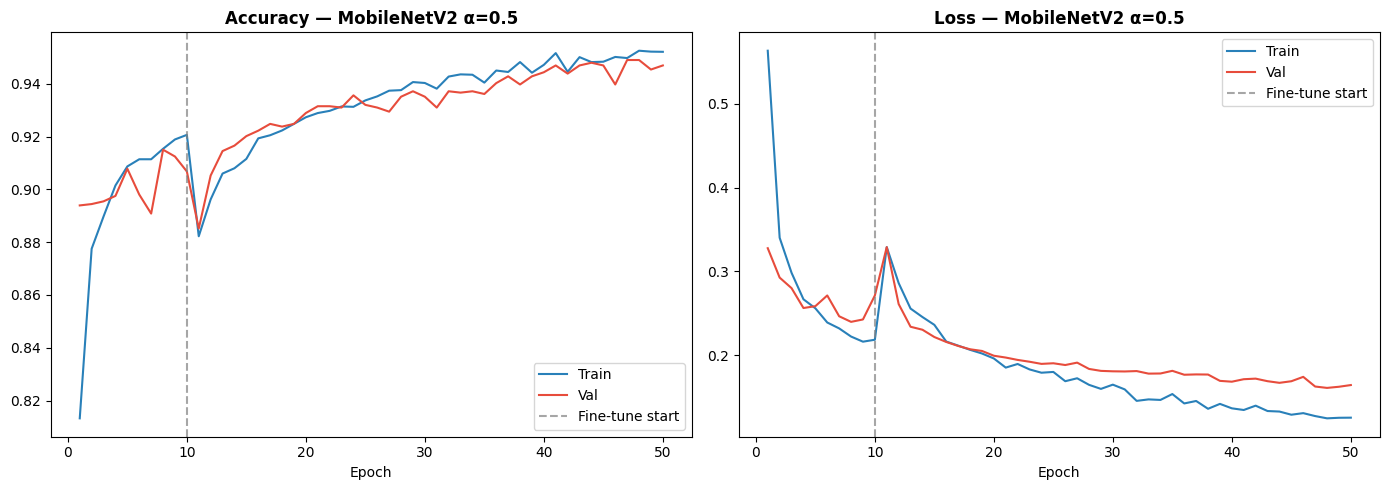

In [12]:
def plot_history(h1, h2, alpha):
    acc  = h1.history['accuracy']        + h2.history['accuracy']
    val  = h1.history['val_accuracy']    + h2.history['val_accuracy']
    loss = h1.history['loss']            + h2.history['loss']
    vloss= h1.history['val_loss']        + h2.history['val_loss']
    ep   = range(1, len(acc)+1)
    split_ep = len(h1.history['accuracy'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for ax, train_m, val_m, title in [
        (ax1, acc,  val,   'Accuracy'),
        (ax2, loss, vloss, 'Loss')
    ]:
        ax.plot(ep, train_m, label='Train', color='#2980B9')
        ax.plot(ep, val_m,   label='Val',   color='#E74C3C')
        ax.axvline(split_ep, color='gray', linestyle='--', alpha=0.7, label='Fine-tune start')
        ax.set_title(f'{title} — MobileNetV2 α={alpha}', fontweight='bold')
        ax.set_xlabel('Epoch'); ax.legend()
    plt.tight_layout()
    plt.savefig(f'/content/training_history_alpha{str(alpha).replace(".","_")}.png', dpi=150)
    plt.show()

plot_history(history1, history2, ALPHA)

# 12. Model Evaluation (Test Set)

This cell acts as the final exam for the model. It tests the trained MobileNetV2 model on completely new, unseen images to check its actual performance.

* **Test Accuracy:** The percentage of times the model guesses the exact correct fruit.
* **Top-3 Accuracy:** The percentage of times the correct fruit is inside the model's top three choices.
* **Test Loss:** A number showing how confident the model is with its errors (lower is better).
* **Automated Check:** The script checks if the final accuracy is 80% or higher. If it is lower than 80%, it prints a warning that you need more training data or a larger model (α=1.0).

In [13]:
print('=== EVALUATING ON TEST SET ===')
test_loss, test_acc, test_top3 = model.evaluate(test_gen, verbose=1)
print(f'\n{"═"*45}')
print(f'  MobileNetV2 α={ALPHA}')
print(f'  Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'  Top-3 Accuracy: {test_top3:.4f} ({test_top3*100:.2f}%)')
print(f'  Test Loss     : {test_loss:.4f}')
print(f'{"═"*45}')

if test_acc < 0.80:
    print('⚠️  Accuracy < 80% — consider more data or α=1.0 model')
else:
    print('✅ Accuracy ≥ 80% — model performing well')

=== EVALUATING ON TEST SET ===
41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 324ms/step - accuracy: 0.9289 - loss: 0.1973 - top3_acc: 0.9992

═════════════════════════════════════════════
  MobileNetV2 α=0.5
  Test Accuracy : 0.9289 (92.89%)
  Top-3 Accuracy: 0.9992 (99.92%)
  Test Loss     : 0.1973
═════════════════════════════════════════════
✅ Accuracy ≥ 80% — model performing well


# 13. Detailed Classification Report

This cell performs an in-depth statistical analysis of the model's predictive performance across every individual class. It first resets the test generator to ensure the order of predictions perfectly aligns with the true labels. It then forces the model to predict the ripeness of every image in the test set. By comparing the model's top predictions (`y_pred`) against the actual ground truth (`y_true`), it generates a comprehensive matrix detailing the Precision, Recall, and F1-Score for all 15 custom fruit classes, identifying exactly which specific fruits the model categorizes best and which ones require more training data.

In [14]:
test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

print('\n=== CLASSIFICATION REPORT ===')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

41/41 ━━━━━━━━━━━━━━━━━━━━ 12s 163ms/step

=== CLASSIFICATION REPORT ===
                    precision    recall  f1-score   support

  Avocado_Overripe     0.6071    0.7391    0.6667        23
      Avocado_Ripe     0.5882    0.4348    0.5000        23
    Avocado_Unripe     0.9333    0.9655    0.9492        29
    Guava_Overripe     0.9804    0.8772    0.9259        57
        Guava_Ripe     0.8571    0.4528    0.5926        53
      Guava_Unripe     0.6903    0.9398    0.7959        83
    Mango_Overripe     0.9854    0.9926    0.9890       136
        Mango_Ripe     0.9876    0.9969    0.9922       320
      Mango_Unripe     1.0000    1.0000    1.0000       104
Pineapple_Overripe     1.0000    1.0000    1.0000        21
    Pineapple_Ripe     1.0000    1.0000    1.0000        18
  Pineapple_Unripe     1.0000    1.0000    1.0000        14
   Banana_Overripe     0.8907    0.9760    0.9314       167
       Banana_Ripe     0.9735    0.8855    0.9274       166
     Banana_Unripe     0.9

# 14. Confusion Matrix Visualization

This cell generates a dual-pane **Confusion Matrix** to visually diagnose the model's exact prediction errors across all 15 fruit ripeness classes.

* **Calculation:** Computes both the raw prediction counts and the row-normalized percentages.
* **Visualization:** Plots the matrices side-by-side using Seaborn heatmaps. The left pane displays raw numbers, while the right pane shows proportional accuracy per class.
* **Diagnostic Utility:** Cross-references the true fruit labels (y-axis) against the model's predicted labels (x-axis) to highlight specific misclassification patterns (e.g., confusing "Ripe" with "Overripe").
* **Output:** Saves the high-resolution figure directly to the Colab environment for review and download.

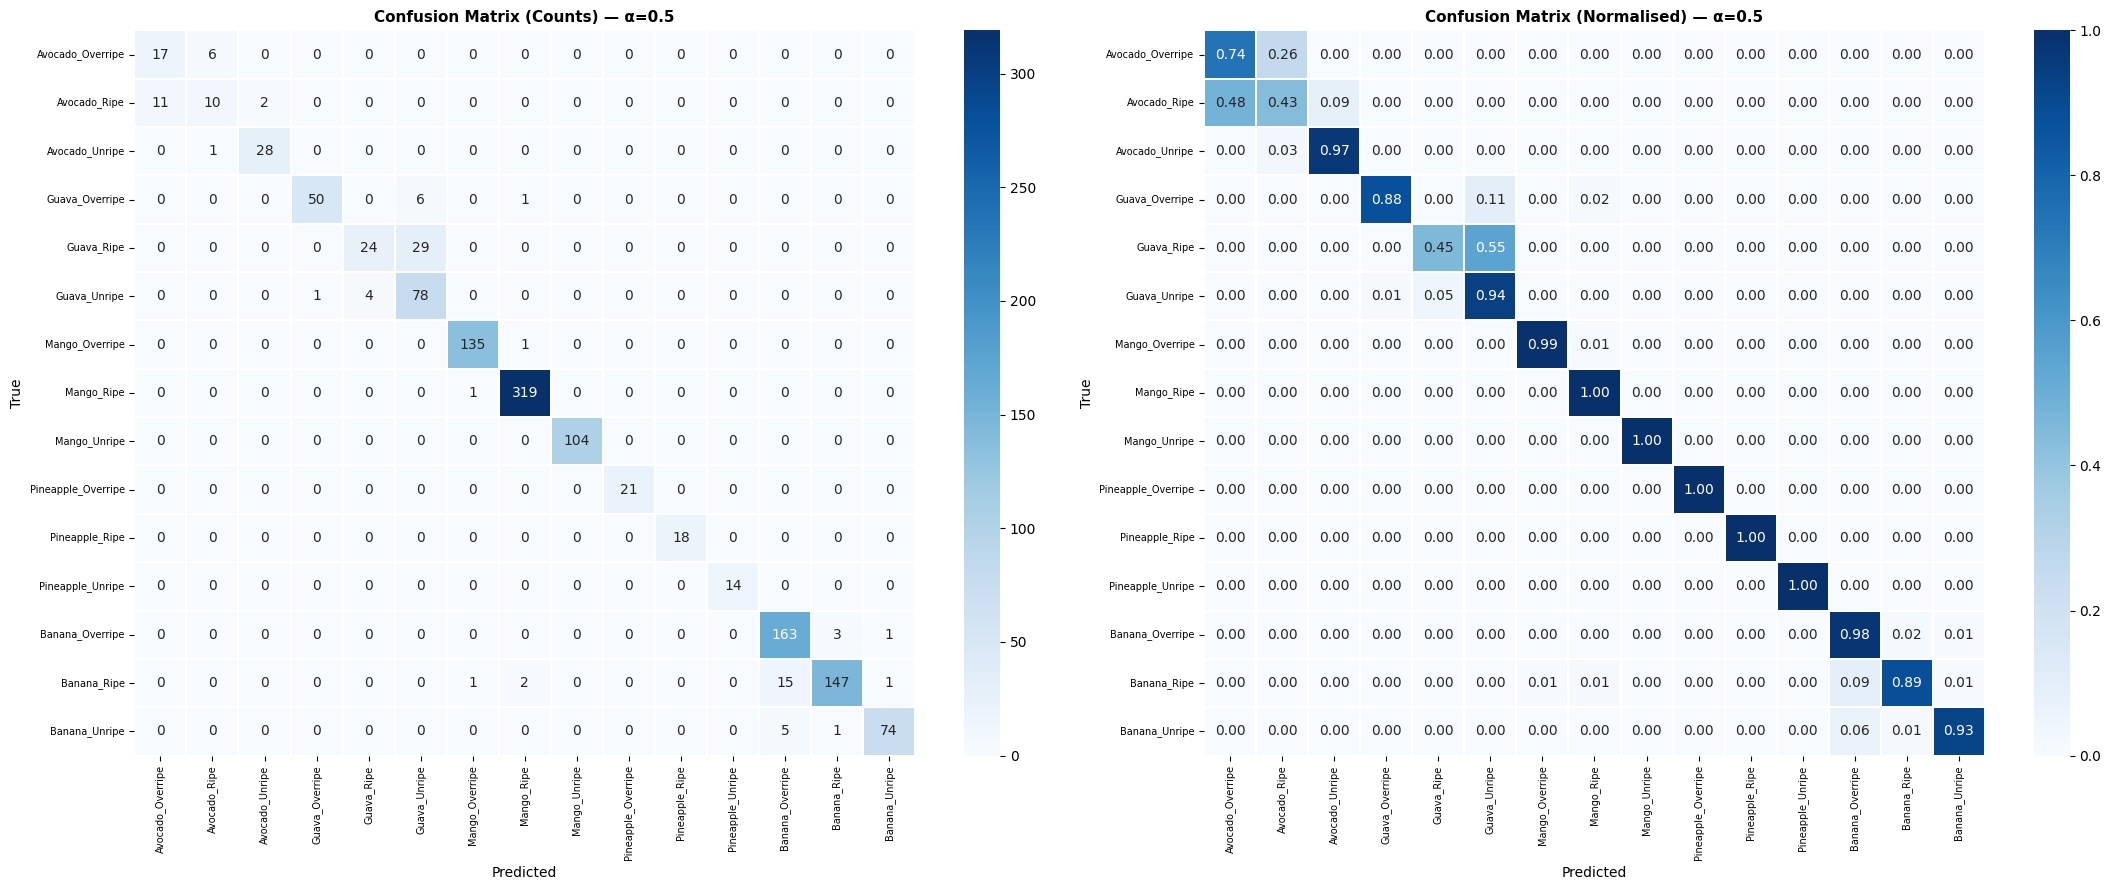

In [15]:
def plot_confusion_matrix(y_true, y_pred, class_names, alpha):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, axes = plt.subplots(1, 2, figsize=(22, 9))
    for ax, data, fmt, title in [
        (axes[0], cm,      'd',   'Counts'),
        (axes[1], cm_norm, '.2f', 'Normalised'),
    ]:
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    ax=ax, linewidths=0.3)
        ax.set_title(f'Confusion Matrix ({title}) — α={alpha}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.tick_params(axis='both', labelsize=7)

    plt.tight_layout()
    plt.savefig(f'/content/confusion_matrix_alpha{str(alpha).replace(".","_")}.png', dpi=150)
    plt.show()

plot_confusion_matrix(y_true, y_pred, CLASS_NAMES, ALPHA)

# 15. Model Export & Edge Deployment (TFLite)

This cell finalizes the training pipeline by persistently saving the fully fine-tuned MobileNetV2 model ( `.keras` ) directly to your Google Drive. Furthermore, it automatically converts and compresses the model into the **TensorFlow Lite** ( `.tflite` ) format. By applying default optimizations, it significantly reduces the model's file size and memory footprint, making it fully prepared for high-speed deployment on mobile applications or edge hardware.

In [16]:
# Save model to Drive
save_path_drive = os.path.join(MODEL_DIR, 'mobilenetv2_alpha05_fruit_ripeness.keras')
model.save(save_path_drive)
print(f'✅ Model saved → {save_path_drive}')

# Also save TFLite for edge deployment
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
tflite_path  = os.path.join(MODEL_DIR, 'mobilenetv2_alpha05_fruit_ripeness.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f'✅ TFLite model saved → {tflite_path}')
print(f'   TFLite size: {os.path.getsize(tflite_path)/1024:.1f} KB')

✅ Model saved → /content/drive/MyDrive/DEEP LEARNING/YOLO26/models/mobilenetv2_alpha05_fruit_ripeness.keras
Saved artifact at '/tmp/tmp2khnk1ye'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 15), dtype=tf.float32, name=None)
Captures:
  131927707866256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131927708216080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131927708216848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131927707867792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131927707866640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131927707866448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131927708217040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131927708217808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131927708217424: TensorSpec(shape=(), dtype=t

# 16. Visualizing Sample Predictions

This cell evaluates the model visually by running inference on a random sample of test images and displaying the results in a grid layout.

* **Image Processing:** Automatically locates test images, resizes them to the required input resolution (`224x224`), and normalizes pixel values.
* **Inference:** Feeds the processed images into the trained MobileNetV2 model to extract prediction probabilities and determine the most likely class.
* **Visual Validation:** Compares the model's top predicted class against the actual ground truth (derived from the folder structure). It overlays the prediction and confidence score on each image, formatting the text in green for correct predictions and red for incorrect errors.
* **Output:** Saves the compiled validation grid as a high-resolution image (`mobilenet_sample_predictions.png`) for manual review.

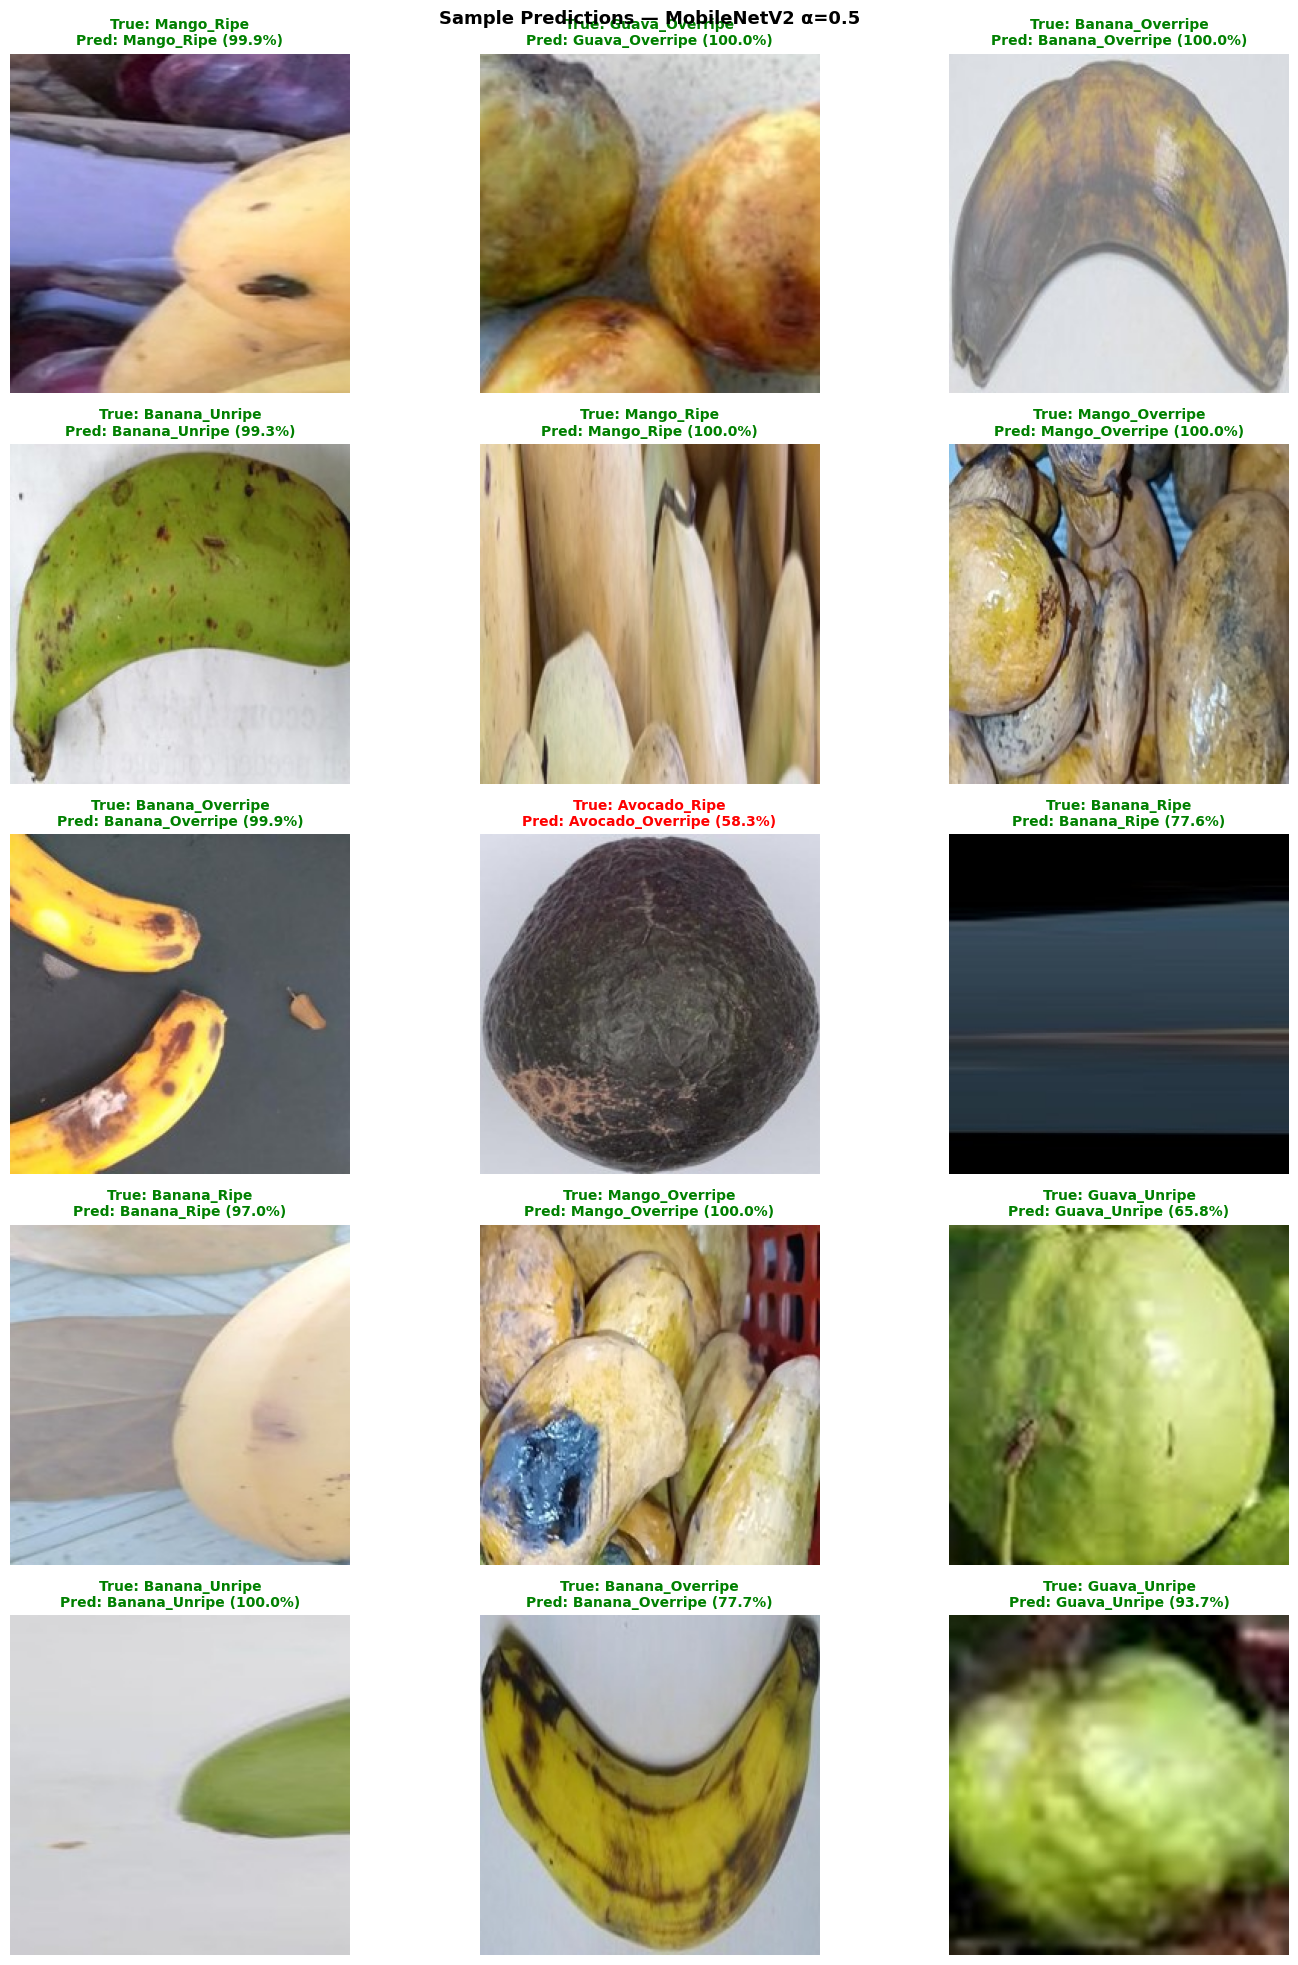

✅ Grid saved → /content/mobilenet_sample_predictions.png



In [20]:
import cv2

def visualise_mobilenet_predictions_grid(test_images_dir, model, class_names, n_samples=15, img_size=224):
    """
    Runs inference on n random test images using MobileNetV2 and shows results in a grid.
    Colors the title text GREEN if correct, RED if incorrect.
    """
    all_imgs = glob.glob(f"{test_images_dir}/**/*.jpg", recursive=True) + \
               glob.glob(f"{test_images_dir}/**/*.png", recursive=True)

    if not all_imgs:
        print("No test images found!")
        return

    sample = random.sample(all_imgs, min(n_samples, len(all_imgs)))

    cols = 3
    rows = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4))
    axes = np.array(axes).flatten()

    for i, img_path in enumerate(sample):
        # Load and preprocess image
        img = Image.open(img_path).convert('RGB')
        img_resized = img.resize((img_size, img_size))
        arr = np.array(img_resized) / 255.0
        arr = np.expand_dims(arr, 0)

        # Run prediction
        raw_probs = model.predict(arr, verbose=0)
        probs = raw_probs[0] # Get the 1D array of probabilities for the single image
        top_idx = np.argmax(probs)
        pred_class = class_names[top_idx]
        confidence = probs[top_idx] * 100

        # Determine true label from folder name
        true_class = Path(img_path).parent.name
        color = 'green' if true_class == pred_class else 'red'

        # Plot
        axes[i].imshow(img)
        axes[i].set_title(f"True: {true_class}\nPred: {pred_class} ({confidence:.1f}%)",
                          fontsize=10, color=color, fontweight='bold')
        axes[i].axis('off')

    # Turn off empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'Sample Predictions — MobileNetV2 α={ALPHA}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/mobilenet_sample_predictions.png', dpi=150)
    plt.show()
    print("✅ Grid saved → /content/mobilenet_sample_predictions.png")

# Run on test images
visualise_mobilenet_predictions_grid(
    test_images_dir=f"{CLF_DIR}/test",
    model=model,
    class_names=CLASS_NAMES,
    n_samples=15,
    img_size=IMG_SIZE
)

print("\n" + "="*60)
print("="*60)